Dans ce notebook nous allons prédire le prix au mètre carré des biens immobiliers en Île-de-France à l’aide de modèles de machine learning (Random Forest et XGBoost), en comparant les performances sur Paris et hors Paris. La séparation Paris - hors Paris permet de meilleurs résultats. Nous évaluons la qualité des prédictions via la MAE, analysons les erreurs, et comparons notre modèle à une approche naïve basée sur la médiane. Nous identifions également les limites du modèle et les tranches de prix où il est le plus performant.

### Imports 

In [ ]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from xgboost import XGBRegressor

In [2]:
os.chdir("../")  

In [3]:
from src.land_value_prediction.multiple_models import (optimize_and_train, 
                                                       predict_xgb_by_zone)

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train_df = pd.read_parquet("data/processed/selected_features/idf_vf_train_selected_features.parquet")
test_df  = pd.read_parquet("data/processed/selected_features/idf_vf_test_selected_features.parquet")
oos_df = pd.read_parquet("data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet")

In [6]:
X_train = train_df.drop(columns=["prix_m2"])
y_train = train_df["prix_m2"]

X_test = test_df.drop(columns=["prix_m2"])
y_test = test_df["prix_m2"]

X_oos = oos_df.drop(columns=["prix_m2"])
y_oos = oos_df["prix_m2"]

In [7]:
X_train.columns

Index(['prix_m2_median_maisons_voisines', 'ratio_terrain_bati',
       'surface_x_type', 'commune_education_score_2013_commune',
       'densite_rel_2000m', 'is_appartement', 'nombre_lots',
       'nb_transport_autre_2000m', 'commune_part_commerce_tourisme',
       'commune_densite_residences_principales_2020', 'distance_paris',
       'nombre_pieces_principales', 'commune_revenu_median_2020',
       'commune_etablissements_1_salarie_2021', 'surface_par_piece',
       'commune_ratio_residences_secondaires_population', 'nb_loisirs_2000m',
       'Taux_moyen_credit_immo_lag1t', 'commune_taux_proprietaires',
       'dist_transport_lourd', 'Evolution_PIB_volume_en_%_base2020_lag4t',
       'nb_services_2000m', 'code_departement'],
      dtype='object')

### 1. Analyses 

In [8]:
fig = px.histogram(X_train, x="prix_m2_median_maisons_voisines", nbins=100, title="Distribution of prix_m2_median_maisons_voisines")
fig.show()

C:\Users\leoco\AppData\Local\Temp\ipykernel_18116\2490331313.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



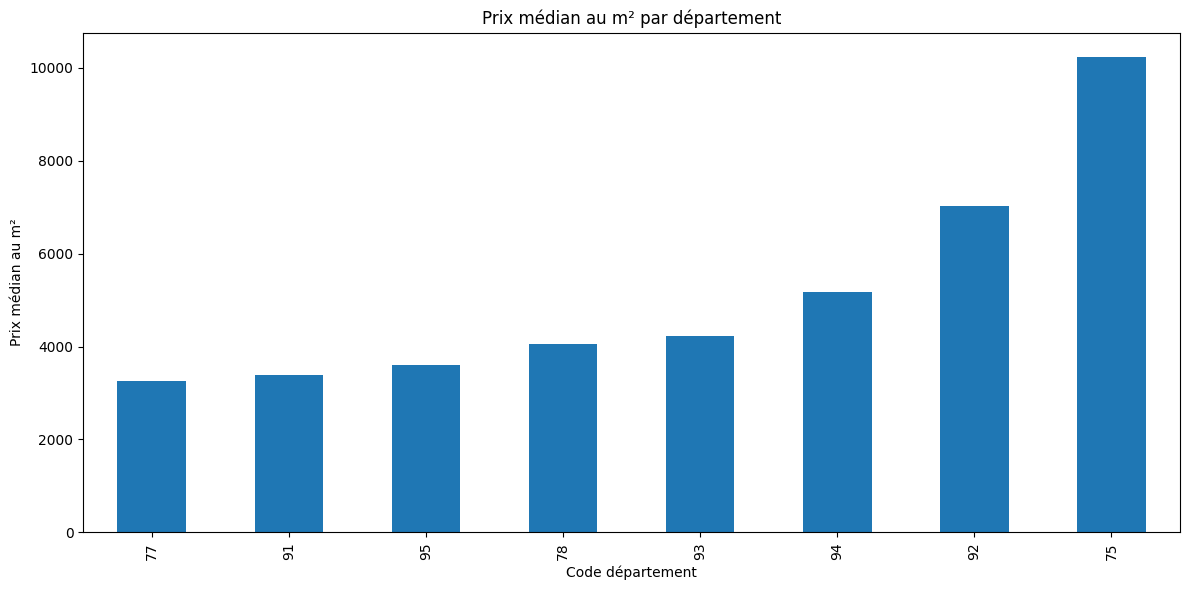

In [9]:
median_price_by_dept = train_df.groupby("code_departement")["prix_m2"].median().sort_values()
plt.figure(figsize=(12,6))
median_price_by_dept.plot(kind="bar")
plt.ylabel("Prix médian au m²")
plt.xlabel("Code département")
plt.title("Prix médian au m² par département")
plt.tight_layout()
plt.show()

### 2. Faire un modèle pour Paris et hors Paris

In [ ]:
# # Définir les hyperparamètres initiaux

# # Xgboost best params trouvés précédemment
# initial_params_xgboost = {'n_estimators': 775,
#                           'max_depth': 12,
#                           'learning_rate': 0.014782011673253295,   
#                           'subsample': 0.9357174649094887,   
#                           'colsample_bytree': 0.6147138328324339,   
#                           'min_child_weight': 5,   
#                           'gamma': 5.722492597986979,   
#                           'reg_alpha': 0.05048493723008041,   
#                           'reg_lambda': 2.3619571121802574}

# # Random Forest initial params 
# initial_params_rf_paris = {'n_estimators': 192, 
#                      'max_depth': 20, 
#                      'min_samples_split': 10, 
#                      'min_samples_leaf': 4, 
#                      'max_features': 0.24223906541740248}

# initial_params_rf_hors_paris = {'n_estimators': 278, 
#                                 'max_depth': 17, 
#                                 'min_samples_split': 3, 
#                                 'min_samples_leaf': 1, 
#                                 'max_features': 0.35739984068330766}

# Paris (75)
X_train_paris = X_train[X_train["code_departement"] == "75"].drop(columns=["code_departement", "distance_paris"])
y_train_paris = y_train[X_train["code_departement"] == "75"]

# Hors Paris
X_train_hors_paris = X_train[X_train["code_departement"] != "75"].drop(columns=["code_departement"])
y_train_hors_paris = y_train[X_train["code_departement"] != "75"]

#### 2.1. Optimisation hyperparamètres sur un jeu de données réduit, entrainement et évaluation du modèle 

In [14]:
# Random Forest optimisation
model_paris_rf, params_paris_rf, score_paris_rf = optimize_and_train(
    X_train_paris, y_train_paris, "Paris (75) RF",
    sample_size=50000, n_trials=5, model_cls=RandomForestRegressor
)
model_hors_paris_rf, params_hors_paris_rf, score_hors_paris_rf = optimize_and_train(
    X_train_hors_paris, y_train_hors_paris, "Hors Paris RF",
    sample_size=50000, n_trials=5, model_cls=RandomForestRegressor
)

# XGBoost optimisation
model_paris_xgb, params_paris_xgb, score_paris_xgb = optimize_and_train(
    X_train_paris, y_train_paris, "Paris (75) XGB",
    sample_size=50000, n_trials=5, model_cls=XGBRegressor
)
model_hors_paris_xgb, params_hors_paris_xgb, score_hors_paris_xgb = optimize_and_train(
    X_train_hors_paris, y_train_hors_paris, "Hors Paris XGB",
    sample_size=50000, n_trials=5, model_cls=XGBRegressor
)

# Résumé des résultats
print("RÉSUMÉ DES OPTIMISATIONS")
print(f"Paris (75) RF - MAE CV: {score_paris_rf:.4f}")
print(f"Hors Paris RF - MAE CV: {score_hors_paris_rf:.4f}")
print(f"Paris (75) XGB - MAE CV: {score_paris_xgb:.4f}")
print(f"Hors Paris XGB - MAE CV: {score_hors_paris_xgb:.4f}")

[I 2025-12-02 15:23:12,251] A new study created in memory with name: RandomForestRegressor_Paris (75) RF



Optimisation pour Paris (75) RF
Utilisation de 50000 observations pour l'optimisation (sur 89875 disponibles)
Recherche GLOBALE des hyperparamètres
Recherche des meilleurs hyperparamètres (5 trials)...


Best trial: 0. Best value: 1548.99:  20%|██        | 1/5 [00:27<01:50, 27.68s/it]

[I 2025-12-02 15:23:39,932] Trial 0 finished with value: 1548.9860320940836 and parameters: {'n_estimators': 231, 'max_depth': 6, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 0.8872400381700094}. Best is trial 0 with value: 1548.9860320940836.


Best trial: 1. Best value: 1524.49:  40%|████      | 2/5 [00:57<01:26, 28.72s/it]

...

[I 2025-12-02 15:33:46,270] Trial 2 finished with value: 967.9307250976562 and parameters: {'n_estimators': 543, 'max_depth': 11, 'learning_rate': 0.19180010690893545, 'subsample': 0.6712573735161597, 'colsample_bytree': 0.3027678837851673, 'min_child_weight': 8, 'gamma': 8.052585780560285, 'reg_alpha': 0.691023723475155, 'reg_lambda': 4.260004881862522}. Best is trial 1 with value: 962.0907104492187.


Best trial: 3. Best value: 932.282:  80%|████████  | 4/5 [02:06<00:33, 33.22s/it]

[I 2025-12-02 15:34:34,910] Trial 3 finished with value: 932.2819458007813 and parameters: {'n_estimators': 646, 'max_depth': 15, 'learning_rate': 0.08368637587839954, 'subsample': 0.5507986031581658, 'colsample_bytree': 0.930236152346682, 'min_child_weight': 10, 'gamma': 3.1055114708202636, 'reg_alpha': 0.175355749049932, 'reg_lambda': 0.9813214419971172}. Best is trial 3 with value: 932.2819458007813.


Best trial: 4. Best value: 880.728: 100%|██████████| 5/5 [02:13<00:00, 26.73s/it]


[I 2025-12-02 15:34:41,991] Trial 4 finished with value: 880.7275268554688 and parameters: {'n_estimators': 850, 'max_depth': 5, 'learning_rate': 0.03499362042320286, 'subsample': 0.7236839616950421, 'colsample_bytree': 0.5608616235314784, 'min_child_weight': 5, 'gamma': 0.4933880771467647, 'reg_alpha': 0.5334776328671024, 'reg_lambda': 2.710753516761285}. Best is trial 4 with value: 880.7275268554688.

Meilleurs hyperparamètres trouvés :
  n_estimators: 850 (initial: N/A)
  max_depth: 5 (initial: N/A)
  learning_rate: 0.03499362042320286 (initial: N/A)
  subsample: 0.7236839616950421 (initial: N/A)
  colsample_bytree: 0.5608616235314784 (initial: N/A)
  min_child_weight: 5 (initial: N/A)
  gamma: 0.4933880771467647 (initial: N/A)
  reg_alpha: 0.5334776328671024 (initial: N/A)
  reg_lambda: 2.710753516761285 (initial: N/A)

Meilleur MAE en CV : 880.7275

Entraînement du modèle final sur Hors Paris XGB (100% des données - 379299 observations)...
Modèle sur Hors Paris XGB entraîné.
RÉSUM

In [15]:
print("Best hyperparameters found for each train:")

print("\nParis RF:")
print(params_paris_rf)

print("\nHors Paris RF:")
print(params_hors_paris_rf)

print("\nParis XGB:")
print(params_paris_xgb)

print("\nHors Paris XGB:")
print(params_hors_paris_xgb)

Best hyperparameters found for each train:

Paris RF:
{'n_estimators': 211, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 0.24101733379644877, 'random_state': 42, 'n_jobs': -1}

Hors Paris RF:
{'n_estimators': 73, 'max_depth': 24, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.37983068736021763, 'random_state': 42, 'n_jobs': -1}

Paris XGB:
{'n_estimators': 844, 'max_depth': 7, 'learning_rate': 0.03274419980005922, 'subsample': 0.7083535007078017, 'colsample_bytree': 0.8556184525158776, 'min_child_weight': 3, 'gamma': 7.6906430982793985, 'reg_alpha': 0.37050875382881, 'reg_lambda': 3.719842460289742, 'random_state': 42, 'n_jobs': -1}

Hors Paris XGB:
{'n_estimators': 850, 'max_depth': 5, 'learning_rate': 0.03499362042320286, 'subsample': 0.7236839616950421, 'colsample_bytree': 0.5608616235314784, 'min_child_weight': 5, 'gamma': 0.4933880771467647, 'reg_alpha': 0.5334776328671024, 'reg_lambda': 2.710753516761285, 'random_state': 42, '

Le XgBoost a de légères meilleures performances. On va donc utiliser ce modèle. 

In [16]:
# Prédiction XGBoost selon Paris ou hors Paris
# Prédictions sur train, test et oos
y_pred_train_xgb = predict_xgb_by_zone(X_train, model_paris_xgb, model_hors_paris_xgb)
y_pred_test_xgb = predict_xgb_by_zone(X_test, model_paris_xgb, model_hors_paris_xgb)
y_pred_oos_xgb = predict_xgb_by_zone(X_oos, model_paris_xgb, model_hors_paris_xgb)

In [17]:
# MAE sur Paris et hors Paris pour le train set
mae_train_paris = mean_absolute_error(
    y_train[X_train["code_departement"] == "75"],
    y_pred_train_xgb[X_train["code_departement"] == "75"]
)
mae_train_hors_paris = mean_absolute_error(
    y_train[X_train["code_departement"] != "75"],
    y_pred_train_xgb[X_train["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le test set
mae_test_paris = mean_absolute_error(
    y_test[test_df["code_departement"] == "75"],
    y_pred_test_xgb[test_df["code_departement"] == "75"]
)
mae_test_hors_paris = mean_absolute_error(
    y_test[test_df["code_departement"] != "75"],
    y_pred_test_xgb[test_df["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le out-of-sample set
mae_oos_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] == "75"],
    y_pred_oos_xgb[oos_df["code_departement"] == "75"]
)
mae_oos_hors_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] != "75"],
    y_pred_oos_xgb[oos_df["code_departement"] != "75"]
)

print(f"MAE train Paris: {mae_train_paris:.2f}")
print(f"MAE train hors Paris: {mae_train_hors_paris:.2f}")
print(f"MAE test Paris: {mae_test_paris:.2f}")
print(f"MAE test hors Paris: {mae_test_hors_paris:.2f}")
print(f"MAE oos Paris: {mae_oos_paris:.2f}")
print(f"MAE oos hors Paris: {mae_oos_hors_paris:.2f}")

MAE train Paris: 1320.27
MAE train hors Paris: 842.25
MAE test Paris: 1476.41
MAE test hors Paris: 847.36
MAE oos Paris: 1520.04
MAE oos hors Paris: 902.22


In [18]:
mae_train = mean_absolute_error(y_train, y_pred_train_xgb)
mae_test = mean_absolute_error(y_test, y_pred_test_xgb)
mae_oos = mean_absolute_error(y_oos, y_pred_oos_xgb)

print(f"MAE train: {mae_train:.2f}")
print(f"MAE test: {mae_test:.2f}")
print(f"MAE oos: {mae_oos:.2f}")

MAE train: 933.82
MAE test: 967.87
MAE oos: 1030.90


#### 2.2 Entrainement Xgboost avec les hyperparamètres initiaux (trouvés à partir d'une recherche d'hyperparamètres sur toute la base dans un autre notebook)

En retestant avec les paramètres initiaux on obtient de meilleurs résultats. Même en augmentant la taille de l'échantillon et le nombre d'essais dans l'optilisation bayésienne on n'arrive pas à de meilleurs résultats. 

In [ ]:
# Entrainement sur Paris
model_paris_xgb_custom = XGBRegressor(**initial_params_xgboost, n_jobs=-1, )
model_paris_xgb_custom.fit(X_train_paris, y_train_paris)

# Entraînement sur hors Paris
model_hors_paris_xgb_custom = XGBRegressor(**initial_params_xgboost)
model_hors_paris_xgb_custom.fit(X_train_hors_paris, y_train_hors_paris)

# Prédictions sur train, test et oos
y_pred_train_xgb = predict_xgb_by_zone(X_train, model_paris_xgb_custom, model_hors_paris_xgb_custom)
y_pred_test_xgb = predict_xgb_by_zone(X_test, model_paris_xgb_custom, model_hors_paris_xgb_custom)
y_pred_oos_xgb = predict_xgb_by_zone(X_oos, model_paris_xgb_custom, model_hors_paris_xgb_custom)

KeyboardInterrupt: 

In [11]:
# MAE sur Paris et hors Paris pour le train set
mae_train_paris = mean_absolute_error(
    y_train[X_train["code_departement"] == "75"],
    y_pred_train_xgb[X_train["code_departement"] == "75"]
)
mae_train_hors_paris = mean_absolute_error(
    y_train[X_train["code_departement"] != "75"],
    y_pred_train_xgb[X_train["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le test set
mae_test_paris = mean_absolute_error(
    y_test[test_df["code_departement"] == "75"],
    y_pred_test_xgb[test_df["code_departement"] == "75"]
)
mae_test_hors_paris = mean_absolute_error(
    y_test[test_df["code_departement"] != "75"],
    y_pred_test_xgb[test_df["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le out-of-sample set
mae_oos_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] == "75"],
    y_pred_oos_xgb[oos_df["code_departement"] == "75"]
)
mae_oos_hors_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] != "75"],
    y_pred_oos_xgb[oos_df["code_departement"] != "75"]
)

print(f"MAE train Paris: {mae_train_paris:.2f}")
print(f"MAE train hors Paris: {mae_train_hors_paris:.2f}")
print(f"MAE test Paris: {mae_test_paris:.2f}")
print(f"MAE test hors Paris: {mae_test_hors_paris:.2f}")
print(f"MAE oos Paris: {mae_oos_paris:.2f}")
print(f"MAE oos hors Paris: {mae_oos_hors_paris:.2f}")

MAE train Paris: 1054.31
MAE train hors Paris: 624.97
MAE test Paris: 1492.00
MAE test hors Paris: 781.98
MAE oos Paris: 1133.55
MAE oos hors Paris: 662.98


In [12]:
mae_train = mean_absolute_error(y_train, y_pred_train_xgb)
mae_test = mean_absolute_error(y_test, y_pred_test_xgb)
mae_oos = mean_absolute_error(y_oos, y_pred_oos_xgb)

print(f"MAE train: {mae_train:.2f}")
print(f"MAE test: {mae_test:.2f}")
print(f"MAE oos: {mae_oos:.2f}")

MAE train: 707.73
MAE test: 919.10
MAE oos: 760.99


#### 2.3 Feature importance 

In [20]:
# Afficher l'importance des features pour le modèle hors Paris XGBoost
importances = model_hors_paris_xgb.feature_importances_
features = X_train_hors_paris.columns

feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
0,prix_m2_median_maisons_voisines,0.241426
9,commune_densite_residences_principales_2020,0.144282
5,is_appartement,0.096097
4,densite_rel_2000m,0.072152
3,commune_education_score_2013_commune,0.067373
6,nombre_lots,0.052741
2,surface_x_type,0.044694
1,ratio_terrain_bati,0.043484
8,commune_part_commerce_tourisme,0.037425
12,commune_revenu_median_2020,0.035445


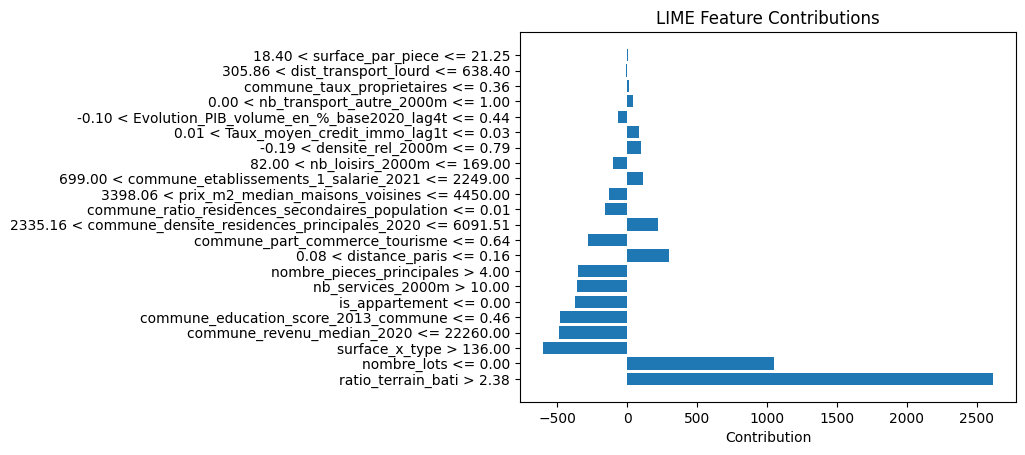

In [29]:
# Retirer la colonne 'code_departement' des features pour LIME
features_for_lime = [col for col in X_test.columns if col != "code_departement"]

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    training_data=X_train[features_for_lime].values,
    feature_names=features_for_lime,
    mode='regression'
)

# Choisir une observation à expliquer
i = 1  

# Sélectionner le bon modèle selon la zone
if X_test.iloc[i]["code_departement"] == "75":
    model = model_hors_paris_xgb
    instance = X_test[features_for_lime].iloc[i].values
else:
    model = model_hors_paris_xgb
    instance = X_test[features_for_lime].iloc[i].values

exp = explainer.explain_instance(
    instance,
    model.predict,
    num_features=30
)

# Afficher l'explication
features, contributions = zip(*exp.as_list())
plt.barh(features, contributions)
plt.xlabel("Contribution")
plt.title("LIME Feature Contributions")
plt.show()

Facteurs positifs majeurs (contribution forte à la hausse)

    surface_x_type <= 72.00 : La contribution positive la plus importante, confirmant qu'une surface modérée est très favorable
    nombre_pieces_principales <= 2.00 : Un logement compact contribue fortement positivement
    commune_education_score_2013_commune > 0.78 : Bon niveau d'éducation dans la commune
    commune_part_commerce_tourisme > 0.80 : Forte présence commerciale/touristique
    densite_rel_2000m > 0.80 : Densité élevée dans l'environnement proche
    distance_paris <= 0.08 : Très proche de Paris
    commune_densite_residences_principales_2020 > 6091.51 : Zone très dense
    prix_m2_median_maisons_voisines dans la fourchette [4448.98, 7684.21] : Prix du voisinage élevé

Facteurs positifs modérés

    Taux_moyen_credit_immo_lag1t > 0.03 : Taux de crédit favorable
    commune_etablissements_1_salarie_2021 dans une certaine fourchette : Tissu économique de micro-entreprises
    is_appartement <= 1.00 : C'est un appartement
    commune_ratio_residences_secondaires_population <= 0.04 : Peu de résidences secondaires
    nb_loisirs_2000m > 264.00 : Nombreuses activités de loisirs à proximité
    Evolution_PIB_volume_en_%_base2020_lag4t > 0.90 : Contexte économique favorable
    commune_taux_proprietaires dans la fourchette [0.36, 0.46] : Taux de propriétaires modéré

Facteurs avec contributions mineures

    nb_services_2000m <= 10.00, commune_revenu_median_2020, nb_transport_autre_2000m, dist_transport_lourd : Contributions très faibles (proche de zéro)
    surface_par_piece dans la fourchette [21.25, 25.00] : Impact minimal

Facteur négatif majeur

    ratio_terrain_bati <= 0.00 : La contribution négative la plus importante, indiquant l'absence de terrain privé

Profil du bien type :

Il s'agit clairement d'un appartement compact et bien situé dans une zone urbaine dense proche de Paris, avec de nombreux commerces et services, dans un quartier prisé avec des prix élevés. L'absence de terrain est le principal élément qui tire la valeur vers le bas, mais elle est largement compensée par tous les avantages de localisation.


### 3. Interpréter les performances du modèle et comprendre ses limites 

#### 3.1 Comparer nos performances à un modèle naif 

Sur le test :

In [22]:
# Calcul de la MAE du modèle naïf (médiane)
mediane_prix_m2 = np.median(y_test[X_test["code_departement"] == "75"])
y_naif = np.repeat(mediane_prix_m2, len(y_test[X_test["code_departement"] == "75"]))
mae_naif = mean_absolute_error(y_test[X_test["code_departement"] == "75"], y_naif)

# Amélioration relative
amelioration = (mae_naif - mean_absolute_error(y_test, y_pred_test_xgb)) / mae_naif * 100

print(f"MAE du modèle naïf (médiane) : {mae_naif:.0f} €/m²")
print(f"MAE de ton modèle : {mean_absolute_error(y_test, y_pred_test_xgb):.0f} €/m²")
print(f"Amélioration relative : {amelioration:.1f}%")

MAE du modèle naïf (médiane) : 1829 €/m²
MAE de ton modèle : 968 €/m²
Amélioration relative : 47.1%


Sur l'out of sample (2025) :

In [23]:
# Calcul de la MAE du modèle naïf (médiane)
mediane_prix_m2 = np.median(y_oos[X_oos["code_departement"] == "75"])
y_naif = np.repeat(mediane_prix_m2, len(y_oos[X_oos["code_departement"] == "75"]))
mae_naif = mean_absolute_error(y_oos[X_oos["code_departement"] == "75"], y_naif)

# Amélioration relative
amelioration = (mae_naif - mean_absolute_error(y_oos, y_pred_oos_xgb)) / mae_naif * 100

print(f"MAE du modèle naïf (médiane) : {mae_naif:.0f} €/m²")
print(f"MAE de ton modèle : {mean_absolute_error(y_oos, y_pred_oos_xgb):.0f} €/m²")
print(f"Amélioration relative : {amelioration:.1f}%")

MAE du modèle naïf (médiane) : 1864 €/m²
MAE de ton modèle : 1031 €/m²
Amélioration relative : 44.7%


Notre modèle fait entre 40 et 50% mieux qu'une prédiction naive. 

#### 3.2 Identifier les observations avec les erreurs les plus fortes (top 10%)


Sur le test :

In [24]:
df_test = test_df.copy()
df_test["pred_prix_m2"] = y_pred_test_xgb.values

# Calcul des erreurs absolues
df_test["erreur_absolue"] = abs(df_test["prix_m2"] - df_test["pred_prix_m2"])

# Seuil pour le top 10% des erreurs
seuil = df_test["erreur_absolue"].quantile(0.9)

# Extraction des observations problématiques
top_10_erreurs = df_test[df_test["erreur_absolue"] >= seuil]

# Tri par erreur décroissante
top_10_erreurs = top_10_erreurs.sort_values("erreur_absolue", ascending=False)

# Affichage des résultats
print(f"Seuil pour le top 10% des erreurs : {seuil:.0f} €/m²")
print(f"Nombre d'observations dans le top 10% : {len(top_10_erreurs)}")

# Afficher les 10 pires prédictions 
cols_to_show = ["prix_m2", "pred_prix_m2", "erreur_absolue", "code_departement"]
top_10_erreurs[cols_to_show]

Seuil pour le top 10% des erreurs : 2241 €/m²
Nombre d'observations dans le top 10% : 11730


,prix_m2,pred_prix_m2,erreur_absolue,code_departement
12459,14585.375000,2369.928711,12215.446289,78
109966,14768.233398,2598.293945,12169.939453,78
83710,15000.000000,3551.700439,11448.299805,93
96922,14802.468750,3512.178711,11290.290039,77
68973,14173.228516,3069.273926,11103.955078,77
...,...,...,...,...
3177,12553.191406,10311.666992,2241.524414,75
30411,8096.774414,10338.297852,2241.523438,75
7092,8125.000000,5883.786621,2241.213379,91
60584,4000.000000,6241.121582,2241.121582,94


In [25]:
top_10_erreurs["code_departement"].value_counts()

code_departement
75    4682
92    1960
78    1159
94    1124
93     941
77     774
91     548
95     542
Name: count, dtype: int64

Comme attendu on fait beaucoup d'erreurs sur Paris. Il y a beaucoup de valeurs aberrantes. 

Le modèle est moins performant sur sur les valeurs extremes (ce qui découle aussi du choix de la métrique):

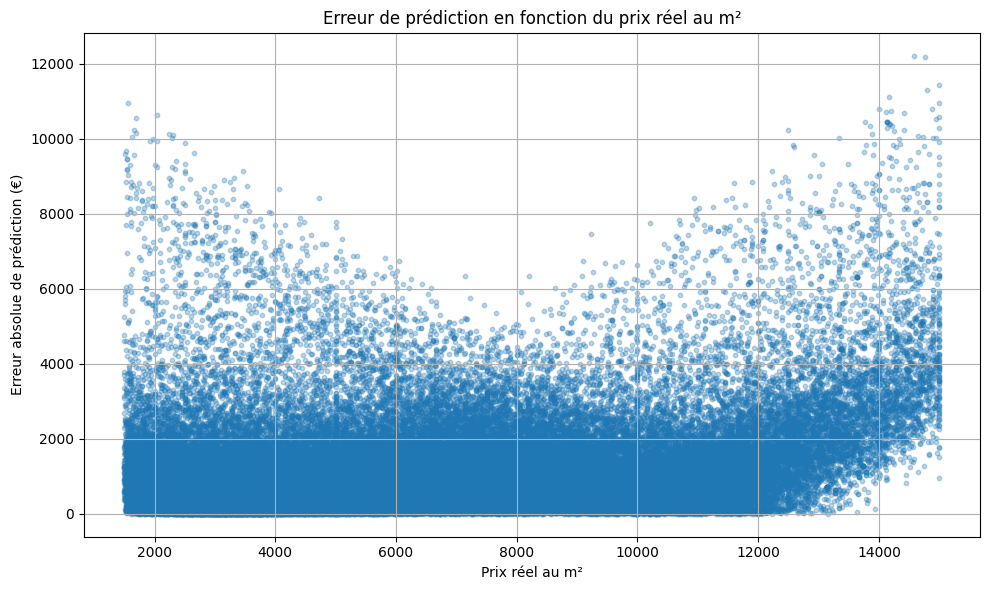

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(df_test["prix_m2"], df_test["erreur_absolue"], alpha=0.3, s=10)
plt.xlabel("Prix réel au m²")
plt.ylabel("Erreur absolue de prédiction (€)")
plt.title("Erreur de prédiction en fonction du prix réel au m²")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# Découper le prix réel en tranches de 1000€
df_test["prix_m2_bin"] = (df_test["prix_m2"] // 1000) * 1000

# Calculer l'erreur absolue moyenne par tranche de prix
erreur_moyenne_par_bin = df_test.groupby("prix_m2_bin")["erreur_absolue"].mean()

# Ajouter la population (nombre d'observations) par tranche de prix au DataFrame
erreur_moyenne_par_bin = erreur_moyenne_par_bin.to_frame("erreur_absolue_moyenne")
erreur_moyenne_par_bin["population"] = df_test.groupby("prix_m2_bin").size()

# Calculer la proportion de la population pour chaque bin
total_population = erreur_moyenne_par_bin["population"].sum()
erreur_moyenne_par_bin["proportion_population"] = (erreur_moyenne_par_bin["population"] / total_population) * 100
erreur_moyenne_par_bin = erreur_moyenne_par_bin.round(4)

erreur_moyenne_par_bin

,erreur_absolue_moyenne,population,proportion_population
prix_m2_bin,,,
1000.0,1130.795898,3778,3.2210
2000.0,686.824402,17748,15.1312
3000.0,569.611206,23784,20.2773
4000.0,733.793213,16168,13.7842
5000.0,958.052979,10819,9.2238
6000.0,1047.421631,8339,7.1095
7000.0,1138.663208,7190,6.1299
8000.0,1154.005493,6624,5.6473
9000.0,1050.943481,5980,5.0983


Le modèle est performant sur la tranche de prix 2000e - 5000e (là où se concentrent une grande partie des ventes), est moyennement performant sur les ventes dont le prix au mètre carré est inférieur à 10 000e mais a des difficulté claires sur les ventes au prix extrêmes. 

#### 3.3 Principales limites identifiées de notre modèle 

La qualité des données semblent limitée malgré nos filtres. On observe des ventes à des prix dérisoires parfois. 
Nous n'avons pas assez de variables expliquant les caractéristiques de la vente (typologie du bien, surface carrez, etat du bien, année de construction du bien, standing du bien, exposition, ect.)